### Measures of Central Tendency (Naive Examples & Practical Guide)

Central tendency helps us find **one single number** that represents the center or typical value of a dataset.

Below are simple, intuitive, everyday examples for all major measures of central tendency, formatted with mathematical notation, variable pronunciations, and code comparisons across **Plain Python**, **Standard Library `statistics`**, and **`NumPy`** / **`SciPy`**.

In [1]:
import statistics
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import statistics
import scipy.stats as stats
import math
from scipy.stats import mstats
import seaborn as sns

--- 
## 1. Arithmetic Mean (Simple Average)

* **What it does:** Shares everything out equally so everyone gets the exact same amount.
* **Mathematical Notation:**
  $$\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i = \frac{x_1 + x_2 + \dots + x_n}{n}$$
  *Where:*
  * $\bar{x}$ (*x-bar*): Sample mean
  * $n$ (*n*): Total number of observations
  * $x_i$ (*x sub i*): Value of the $i$-th individual observation
  * $\sum$ (*capital Sigma*): Summation operator (add all values together)
* **Naive Example:** 3 friends have candies — Friend A has 2, Friend B has 3, and Friend C has 10 ($x_1 = 2, x_2 = 3, x_3 = 10, n = 3$). 
  $$\bar{x} = \frac{2 + 3 + 10}{3} = \frac{15}{3} = 5 \text{ candies per friend}$$
* **When to use:** When there are no extreme high/low values (outliers) skewing the result.

Plain Python calculation:  5.0 candies per friend
statistics.mean() function: 5.0 candies per friend
np.mean() function:         5.0 candies per friend


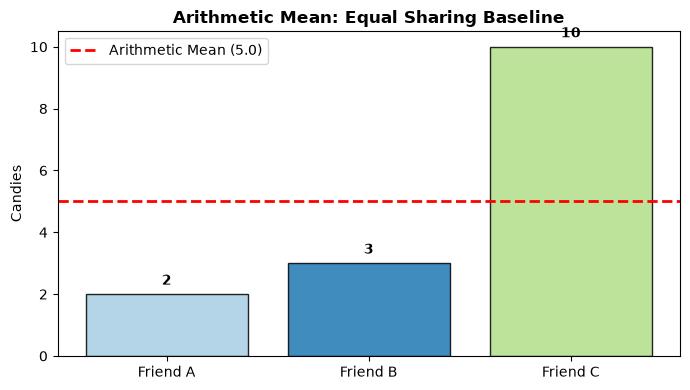

In [3]:
# 1. Arithmetic Mean Example
candies = [2, 3, 10]
friends = ['Friend A', 'Friend B', 'Friend C']
# Plain Python
mean_python = sum(candies) / len(candies)

# Standard Library (statistics)
mean_stats = statistics.mean(candies)

# NumPy Library
mean_np = np.mean(candies)

print(f"Plain Python calculation:  {mean_python:.1f} candies per friend")
print(f"statistics.mean() function: {mean_stats:.1f} candies per friend")
print(f"np.mean() function:         {mean_np:.1f} candies per friend")

# --- Visual Representation ---
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(friends, candies, color=['#a6cee3', '#1f78b4', '#b2df8a'], edgecolor='black', alpha=0.85)
ax.axhline(mean_np, color='red', linestyle='--', linewidth=2, label=f'Arithmetic Mean ({mean_np:.1f})')
ax.set_ylabel('Candies')
ax.set_title('Arithmetic Mean: Equal Sharing Baseline', fontweight='bold')
ax.legend(loc='upper left')
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.2, f'{yval}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

--- 
## 2. Median (Middle Value)

* **What it does:** Finds the exact middle observation after sorting data from smallest to largest.
* **Mathematical Notation:**
  $$\tilde{x} = \begin{cases} 
  x_{\left(\frac{n+1}{2}\right)}, & \text{if } n \text{ is odd} \\
  \frac{x_{\left(\frac{n}{2}\right)} + x_{\left(\frac{n}{2} + 1\right)}}{2}, & \text{if } n \text{ is even}
  \end{cases}$$
  *Where:*
  * $\tilde{x}$ (*x-tilde* or *m*): Median
  * $n$ (*n*): Sample size
  * $x_{(k)}$ (*x sub k in parentheses*): The $k$-th value in sorted order
* **Naive Example:** 5 daily wages: \$10, \$12, \$15, \$20, and \$1,000 ($n = 5$, odd). The sorted order puts \$15 right in the middle ($3^{\text{rd}}$ position). The \$1,000 outlier does not pull the median up!
* **When to use:** When data contains severe outliers or skewed values (like salaries or housing prices).

Plain Python calculation:  $15.00
statistics.median() function: $15.00
np.median() function:         $15.00


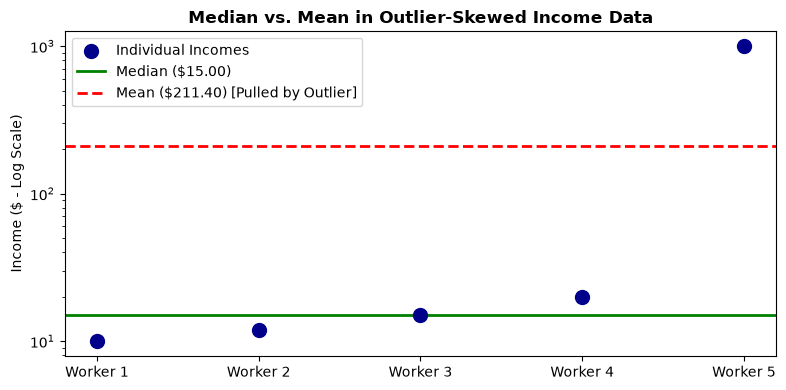

In [4]:
#  Median Example
incomes = [10, 12, 15, 20, 1000]

# Plain Python
sorted_incomes = sorted(incomes)
n = len(sorted_incomes)
if n % 2 == 1:
    median_python = sorted_incomes[n // 2]
else:
    median_python = (sorted_incomes[(n // 2) - 1] + sorted_incomes[n // 2]) / 2

# Standard Library (statistics)
median_stats = statistics.median(incomes)

# NumPy Library
median_np = np.median(incomes)
mean_inc = np.mean(incomes)

print(f"Plain Python calculation:  ${median_python:.2f}")
print(f"statistics.median() function: ${median_stats:.2f}")
print(f"np.median() function:         ${median_np:.2f}")

# --- Visual Representation ---
fig, ax = plt.subplots(figsize=(8, 4))
x_positions = range(1, len(incomes) + 1)
ax.scatter(x_positions, incomes, color='darkblue', s=100, zorder=3, label='Individual Incomes')
ax.axhline(median_np, color='green', linestyle='-', linewidth=2, label=f'Median (${median_np:.2f})')
ax.axhline(mean_inc, color='red', linestyle='--', linewidth=2, label=f'Mean (${mean_inc:.2f}) [Pulled by Outlier]')
ax.set_yscale('log') # options are 'linear', 'log', 'symlog', 'logit' 
ax.set_xticks(list(x_positions))
ax.set_xticklabels([f'Worker {i}' for i in x_positions])
ax.set_ylabel('Income ($ - Log Scale)')
ax.set_title('Median vs. Mean in Outlier-Skewed Income Data', fontweight='bold')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

--- 
## 3. Mode (Most Frequent Value)

* **What it does:** Identifies the value or category that appears most often.
* **Mathematical Notation:**
  $$\text{Mode} = \arg\max_{x} \text{Frequency}(x)$$
  *Where:*
  * $\arg\max$ (*arg-max* or *argument of the maximum*): The argument $x$ that produces the maximum value for the frequency function.
  * $\text{Frequency}(x)$: Count of occurrences of value $x$.
* **Naive Example:** 6 people pick ice cream flavors: `['Vanilla', 'Chocolate', 'Vanilla', 'Strawberry', 'Vanilla', 'Chocolate']`.
  $$\text{Frequency}(\text{Vanilla}) = 3 \implies \text{Mode} = \text{Vanilla}$$
* **When to use:** Ideal for categorical or nominal data (labels/names) where numerical operations are impossible.

Plain Python calculation:  Vanilla
statistics.mode() function: Vanilla
scipy.stats.mode() function: 3 (for numerical array [1, 2, 2, 3, 3, 3, 4])


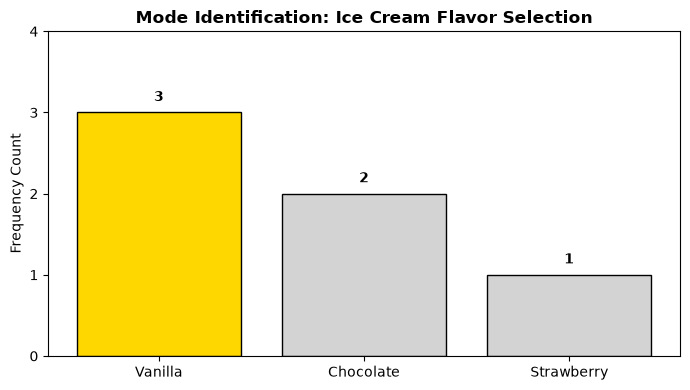

In [12]:

# 3. Mode Example
flavors = ['Vanilla', 'Chocolate', 'Vanilla', 'Strawberry', 'Vanilla', 'Chocolate']
numerical_data = [1, 2, 2, 3, 3, 3, 4]

# Plain Python (using Counter)
counts = Counter(flavors)
mode_python = counts.most_common(1)[0][0]

# Standard Library (statistics)
mode_stats = statistics.mode(flavors)

# SciPy Library (For numerical arrays, as NumPy lacks a direct built-in mode method)
mode_scipy = stats.mode(numerical_data, keepdims=True).mode[0]

print(f"Plain Python calculation:  {mode_python}")
print(f"statistics.mode() function: {mode_stats}")
print(f"scipy.stats.mode() function: {mode_scipy} (for numerical array {numerical_data})")

# --- Visual Representation ---
fig, ax = plt.subplots(figsize=(7, 4))
categories = list(counts.keys())
frequencies = list(counts.values())
bar_colors = ['gold' if k == mode_stats else 'lightgray' for k in categories]

bars = ax.bar(categories, frequencies, color=bar_colors, edgecolor='black')
ax.set_ylabel('Frequency Count')
ax.set_title('Mode Identification: Ice Cream Flavor Selection', fontweight='bold')
ax.set_yticks(range(0, max(frequencies) + 2))
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2.0, bar.get_height() + 0.1, f'{bar.get_height()}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

--- 
## 4. Geometric Mean (Compounding Growth Average)

* **What it does:** Calculates the true central rate for items that grow multiplicatively or by percentages.
* **Mathematical Notation:**
  $$G = \left( \prod_{i=1}^{n} x_i \right)^{\frac{1}{n}} = \sqrt[n]{x_1 \cdot x_2 \cdot \dots \cdot x_n}$$
  *Where:*
  * $G$ (*G*): Geometric mean
  * $\prod$ (*capital Pi*): Product operator (multiply all values together)
  * $n$ (*n*): Total number of multiplication factors
  * $x_i$ (*x sub i*): Growth multiplier for period $i$
* **Naive Example:** An investment grows by +100% in Year 1 ($x_1 = 2.0$) and drops by -50% in Year 2 ($x_2 = 0.5$).
  $$G = \sqrt{2.0 \times 0.5} = \sqrt{1.0} = 1.0 \implies 0\% \text{ net compounding growth rate}$$
* **When to use:** Multiplicative processes, financial returns, compound interest, or growth rates.

Plain Python calculation:       1.00
statistics.geometric_mean():    1.00
scipy.stats.gmean():            1.00
NumPy (log-mean exponentiated): 1.00


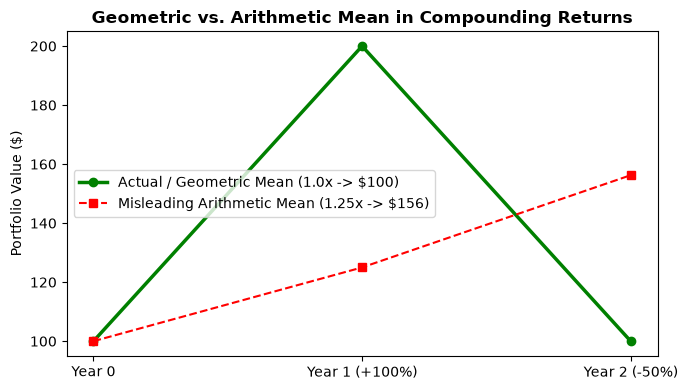

In [17]:
# Geometric Mean Example
multipliers = [2.0, 0.5]

# Plain Python
gmean_python = math.prod(multipliers) ** (1 / len(multipliers))

# Standard Library (statistics)
gmean_stats = statistics.geometric_mean(multipliers)

# SciPy Library
gmean_scipy = stats.gmean(multipliers)

# NumPy alternative (using log-sum-exp trick)
gmean_np = np.exp(np.mean(np.log(multipliers)))
amean_np = np.mean(multipliers)

print(f"Plain Python calculation:       {gmean_python:.2f}")
print(f"statistics.geometric_mean():    {gmean_stats:.2f}")
print(f"scipy.stats.gmean():            {gmean_scipy:.2f}")
print(f"NumPy (log-mean exponentiated): {gmean_np:.2f}")

# --- Visual Representation ---
fig, ax = plt.subplots(figsize=(7, 4))
years = ['Year 0', 'Year 1 (+100%)', 'Year 2 (-50%)']
actual_wealth = [100, 100 * 2.0, 100 * 2.0 * 0.5]
arithmetic_growth = [100, 100 * amean_np, 100 * (amean_np**2)]

ax.plot(years, actual_wealth, marker='o', linewidth=2.5, color='green', label=f'Actual / Geometric Mean (1.0x -> $100)')
ax.plot(years, arithmetic_growth, marker='s', linestyle='--', color='red', label=f'Misleading Arithmetic Mean ({amean_np:.2f}x -> ${arithmetic_growth[-1]:.0f})')
ax.set_ylabel('Portfolio Value ($)')
ax.set_title('Geometric vs. Arithmetic Mean in Compounding Returns', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

--- 
## 5. Harmonic Mean (Average Rate / Speed)

* **What it does:** Calculates the true central value when measuring rates or ratios over fixed distances/work units.
* **Mathematical Notation:**
  $$H = \frac{n}{\sum_{i=1}^{n} \frac{1}{x_i}} = \frac{n}{\frac{1}{x_1} + \frac{1}{x_2} + \dots + \frac{1}{x_n}}$$
  *Where:*
  * $H$ (*H*): Harmonic mean
  * $n$ (*n*): Count of rates
  * $x_i$ (*x sub i*): Individual speed or rate value
  * $\frac{1}{x_i}$ (*one over x sub i*): Reciprocal of $x_i$
* **Naive Example:** Travel 60 km at $60\text{ km/h}$ ($x_1 = 60$, takes 1 hr) and return 60 km at $20\text{ km/h}$ ($x_2 = 20$, takes 3 hrs).
  $$H = \frac{2}{\frac{1}{60} + \frac{1}{20}} = \frac{2}{\frac{1 + 3}{60}} = \frac{2}{\frac{4}{60}} = 30\text{ km/h}$$
* **When to use:** Average speeds, rates, ratios, or hardware throughput.

Plain Python calculation:    30.0 km/h
statistics.harmonic_mean(): 30.0 km/h
scipy.stats.hmean():         30.0 km/h
NumPy array reciprocals:     30.0 km/h


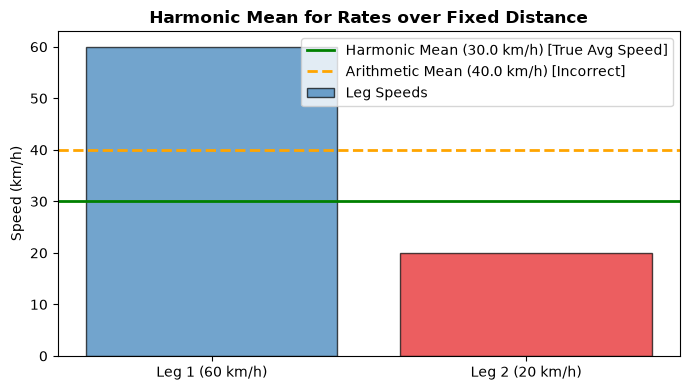

In [18]:
# Harmonic Mean Example
speeds = [60, 20]

# Plain Python
hmean_python = len(speeds) / sum(1 / x for x in speeds)

# Standard Library (statistics)
hmean_stats = statistics.harmonic_mean(speeds)

# SciPy Library
hmean_scipy = stats.hmean(speeds)

# NumPy alternative
hmean_np = len(speeds) / np.sum(1.0 / np.array(speeds))
amean_speeds = np.mean(speeds)

print(f"Plain Python calculation:    {hmean_python:.1f} km/h")
print(f"statistics.harmonic_mean(): {hmean_stats:.1f} km/h")
print(f"scipy.stats.hmean():         {hmean_scipy:.1f} km/h")
print(f"NumPy array reciprocals:     {hmean_np:.1f} km/h")

# --- Visual Representation ---
fig, ax = plt.subplots(figsize=(7, 4))
legs = ['Leg 1 (60 km/h)', 'Leg 2 (20 km/h)']
ax.bar(legs, speeds, color=['#377eb8', '#e41a1c'], alpha=0.7, edgecolor='black', label='Leg Speeds')
ax.axhline(hmean_np, color='green', linestyle='-', linewidth=2, label=f'Harmonic Mean ({hmean_np:.1f} km/h) [True Avg Speed]')
ax.axhline(amean_speeds, color='orange', linestyle='--', linewidth=2, label=f'Arithmetic Mean ({amean_speeds:.1f} km/h) [Incorrect]')
ax.set_ylabel('Speed (km/h)')
ax.set_title('Harmonic Mean for Rates over Fixed Distance', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

--- 
## Trimmed Mean (Fair Average without Extremes)

* **What it does:** Computes the mean after discarding a fixed percentage of extreme values from both tails.
* **Mathematical Notation:**
  $$\bar{x}_{\alpha} = \frac{1}{n - 2k} \sum_{i=k+1}^{n-k} x_{(i)}$$
  *Where:*
  * $\bar{x}_{\alpha}$ (*x-bar sub alpha*): Trimmed mean with proportion $\alpha$ cut from each tail
  * $k$ (*k*): Number of extreme elements dropped from each side ($k = \lfloor n \cdot \alpha \rfloor$)
  * $x_{(i)}$ (*x sub i in parentheses*): Data points in sorted ascending order
* **Naive Example:** 5 diving scores: `[1, 8, 8, 9, 10]` ($n = 5$). Cut $20\%$ from both ends ($k = 1$). Drop lowest `1` and highest `10`. Average remaining `[8, 8, 9]`:
  $$\bar{x}_{0.20} = \frac{8 + 8 + 9}{3} = \frac{25}{3} \approx 8.33$$
* **When to use:** Olympic scoring, noisy sensor readings, or metrics where low/high noise should be removed.

Plain Python calculation: 8.33
scipy.stats.trim_mean():   8.33


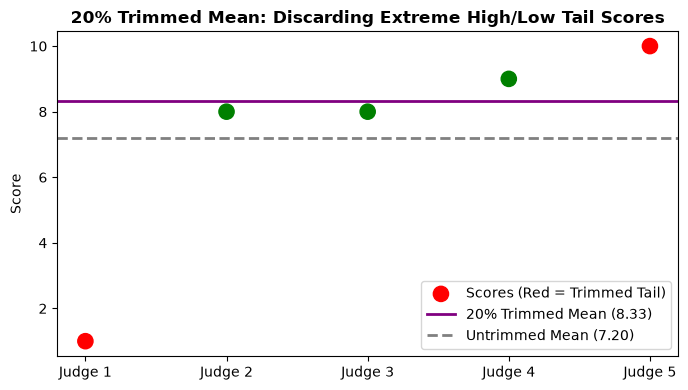

In [19]:
# Trimmed Mean Example (Trim 20% from each end)
scores = [1, 8, 8, 9, 10]
proportion = 0.20

# Plain Python
sorted_scores = sorted(scores)
k = int(len(sorted_scores) * proportion)
trimmed_scores = sorted_scores[k : len(sorted_scores) - k]
tmean_python = sum(trimmed_scores) / len(trimmed_scores)

# SciPy Library (standard implementation for trimmed mean)
tmean_scipy = stats.trim_mean(scores, proportiontocut=proportion)
amean_scores = np.mean(scores)

print(f"Plain Python calculation: {tmean_python:.2f}")
print(f"scipy.stats.trim_mean():   {tmean_scipy:.2f}")

# --- Visual Representation ---
fig, ax = plt.subplots(figsize=(7, 4))
x_indices = range(len(scores))
colors = ['red' if i < k or i >= len(scores) - k else 'green' for i in range(len(scores))]
ax.scatter(x_indices, sorted_scores, color=colors, s=120, zorder=3, label='Scores (Red = Trimmed Tail)')
ax.axhline(tmean_scipy, color='purple', linestyle='-', linewidth=2, label=f'20% Trimmed Mean ({tmean_scipy:.2f})')
ax.axhline(amean_scores, color='gray', linestyle='--', linewidth=2, label=f'Untrimmed Mean ({amean_scores:.2f})')
ax.set_xticks(list(x_indices))
ax.set_xticklabels([f'Judge {i+1}' for i in x_indices])
ax.set_ylabel('Score')
ax.set_title('20% Trimmed Mean: Discarding Extreme High/Low Tail Scores', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

--- 
## 7. Winsorized Mean (Capped Average)

* **What it does:** Caps extreme values by replacing them with the nearest non-extreme values, maintaining sample size $n$.
* **Mathematical Notation:**
  $$\bar{x}_{w,\alpha} = \frac{1}{n} \left( k \cdot x_{(k+1)} + \sum_{i=k+1}^{n-k} x_{(i)} + k \cdot x_{(n-k)} \right)$$
  *Where:*
  * $\bar{x}_{w,\alpha}$ (*x-bar w sub alpha*): Winsorized mean
  * $k$ (*k*): Count of extreme values capped on each end ($k = \lfloor n \cdot \alpha \rfloor$)
  * $x_{(k+1)}$ (*x sub k plus 1*): Smallest retained boundary value
  * $x_{(n-k)}$ (*x sub n minus k*): Largest retained boundary value
* **Naive Example:** 5 daily screen times in minutes: `[10, 60, 90, 120, 1440]` ($n = 5$). Capping 20% ($k = 1$) converts `10` to `60` and `1440` to `120`, resulting in modified data `[60, 60, 90, 120, 120]`:
  $$\bar{x}_{w,0.20} = \frac{60 + 60 + 90 + 120 + 120}{5} = \frac{450}{5} = 90.0\text{ minutes}$$
* **When to use:** When extreme outliers must be tamed without discarding data points from the total count.

# Winsorized Mean (Capped Average)

Instead of throwing extreme numbers away entirely (like a trimmed mean would), a **Winsorized mean** caps extreme values by replacing them with the nearest "normal" (non-extreme) values.

---

### Step-by-Step Example (20% Capping)

#### 1. Sort the data from lowest to highest
$$\text{Data}: [10, 60, 90, 120, 1440] \quad (n = 5)$$

#### 2. Calculate how many numbers to replace
For a 20% Winsorization ($k$ values on each tail):
$$k = n \times 0.20 = 5 \times 0.20 = 1$$

You replace the **1 lowest** value and the **1 highest** value.

#### 3. Replace extreme values with nearest neighbors
* **Lowest value (10)** $\rightarrow$ replaced by its neighbor **60**
* **Highest value (1440)** $\rightarrow$ replaced by its neighbor **120**

#### 4. Modified Dataset
$$\text{Original}: [10, 60, 90, 120, 1440]$$
$$\text{Winsorized}: [60, 60, 90, 120, 120]$$

#### 5. Calculate the Winsorized Mean
$$\text{Winsorized Mean} = \frac{60 + 60 + 90 + 120 + 120}{5} = \frac{450}{5} = 90\text{ minutes (1.5 hours)}$$

---


Plain Python capped data:  [np.int64(60), np.int64(60), np.int64(90), np.int64(120), np.int64(120)]
Plain Python calculation:  90.0 minutes
scipy.stats.mstats:        90.0 minutes


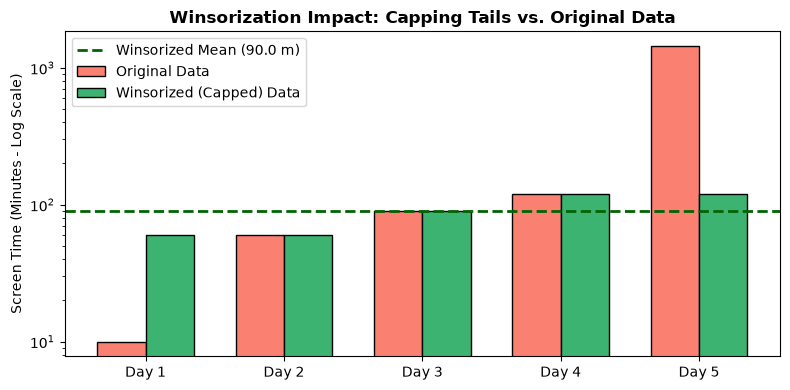

In [21]:
# 7. Winsorized Mean Example (Cap 20% on each end)

screen_time = np.array([10, 60, 90, 120, 1440])
limits = [0.20, 0.20]

# Plain Python
sorted_time = sorted(screen_time)
n = len(sorted_time)
k = int(n * limits[0])
low_val = sorted_time[k]
high_val = sorted_time[n - k - 1]
capped_data = [low_val if x < low_val else high_val if x > high_val else x for x in sorted_time]
wmean_python = sum(capped_data) / n

# SciPy MStats Library
winsorized_array = mstats.winsorize(screen_time, limits=limits)
wmean_scipy = np.mean(winsorized_array)

print(f"Plain Python capped data:  {capped_data}")
print(f"Plain Python calculation:  {wmean_python:.1f} minutes")
print(f"scipy.stats.mstats:        {wmean_scipy:.1f} minutes")

# --- Visual Representation ---
fig, ax = plt.subplots(figsize=(8, 4))
indices = np.arange(len(screen_time))
width = 0.35
ax.bar(indices - width/2, screen_time, width, label='Original Data', color='salmon', edgecolor='black')
ax.bar(indices + width/2, capped_data, width, label='Winsorized (Capped) Data', color='mediumseagreen', edgecolor='black')
ax.axhline(wmean_scipy, color='darkgreen', linestyle='--', linewidth=2, label=f'Winsorized Mean ({wmean_scipy:.1f} m)')
ax.set_yscale('log')
ax.set_xticks(indices)
ax.set_xticklabels([f'Day {i+1}' for i in indices])
ax.set_ylabel('Screen Time (Minutes - Log Scale)')
ax.set_title('Winsorization Impact: Capping Tails vs. Original Data', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

--- Central Tendency ---
Mean:                  51.73
10% Trimmed Mean:      49.39
Median:                49.06
Mode:                  23.80 (Count: 1)

--- Dispersion & Position ---
Range:                 176.20
Q1 (25th Percentile):  44.09
Q2 / Median:           49.06
Q3 (75th Percentile):  55.09
IQR:                   11.00
Sample Variance (s²):  469.00
Sample Std Dev (s):    21.66 (ddof=1)
Pop Std Dev (σ):       21.55 (ddof=0)
Coeff. of Variation:   41.87%

IQR Outlier Bounds:    [27.59, 71.59]
Detected Outliers:     [ 23.80254896 180.         200.        ]


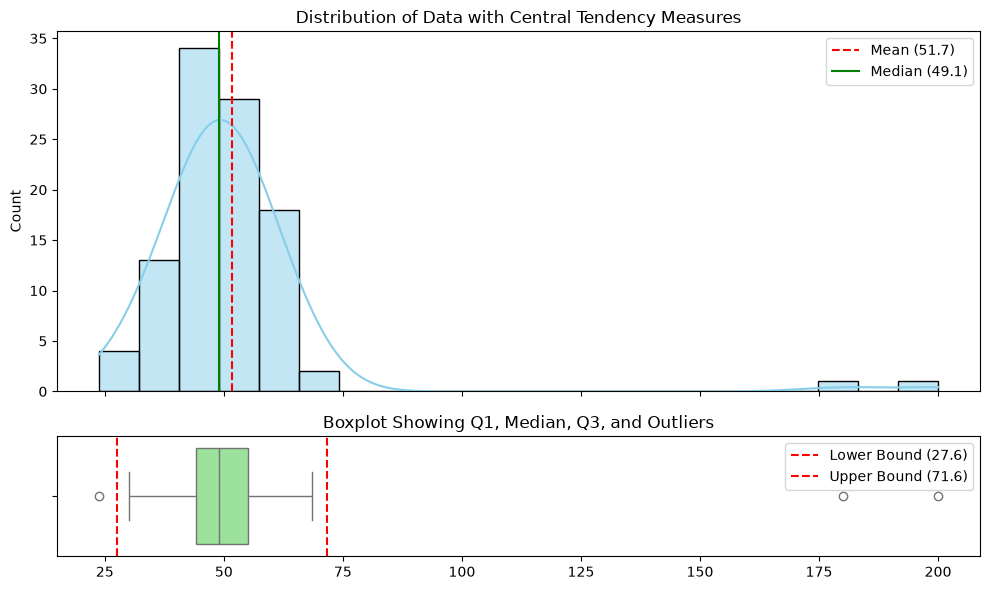

In [2]:


# Set seed for reproducibility
np.random.seed(42)

# 1. Generate Synthetic Dataset with Skewness & Outliers
data = np.concatenate([np.random.normal(loc=50, scale=10, size=100), [180, 200]])

# 2. Measures of Central Tendency
mean_val = np.mean(data)
trimmed_mean_10 = stats.trim_mean(data, proportiontocut=0.10)
median_val = np.median(data)
mode_res = stats.mode(data, keepdims=True)

print("--- Central Tendency ---")
print(f"Mean:                  {mean_val:.2f}")
print(f"10% Trimmed Mean:      {trimmed_mean_10:.2f}")
print(f"Median:                {median_val:.2f}")
print(f"Mode:                  {mode_res.mode[0]:.2f} (Count: {mode_res.count[0]})")

# 3. Measures of Dispersion & Position
range_val = np.ptp(data) # Peak-to-peak (Max - Min)
q1, q2, q3 = np.percentile(data, [25, 50, 75], method='linear')
iqr_val = q3 - q1

# Variance & Standard Deviation (Sample vs Population)
sample_var = np.var(data, ddof=1)
sample_std = np.std(data, ddof=1)
pop_std = np.std(data, ddof=0)

# Coefficient of Variation
cv_val = (sample_std / mean_val) * 100

print("\n--- Dispersion & Position ---")
print(f"Range:                 {range_val:.2f}")
print(f"Q1 (25th Percentile):  {q1:.2f}")
print(f"Q2 / Median:           {q2:.2f}")
print(f"Q3 (75th Percentile):  {q3:.2f}")
print(f"IQR:                   {iqr_val:.2f}")
print(f"Sample Variance (s²):  {sample_var:.2f}")
print(f"Sample Std Dev (s):    {sample_std:.2f} (ddof=1)")
print(f"Pop Std Dev (σ):       {pop_std:.2f} (ddof=0)")
print(f"Coeff. of Variation:   {cv_val:.2f}%")

# 4. Outlier Detection using IQR Rule
lower_bound = q1 - 1.5 * iqr_val
upper_bound = q3 + 1.5 * iqr_val
outliers = data[(data < lower_bound) | (data > upper_bound)]
print(f"\nIQR Outlier Bounds:    [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Detected Outliers:     {outliers}")

# 5. Visualization (Histogram + Boxplot)
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Histogram with KDE
sns.histplot(data, kde=True, ax=axes[0], color='skyblue')
axes[0].axvline(mean_val, color='red', linestyle='--', label=f'Mean ({mean_val:.1f})')
axes[0].axvline(median_val, color='green', linestyle='-', label=f'Median ({median_val:.1f})')
axes[0].set_title('Distribution of Data with Central Tendency Measures')
axes[0].legend()

# Boxplot showing Quartiles & IQR
sns.boxplot(x=data, ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot Showing Q1, Median, Q3, and Outliers')
axes[1].axvline(lower_bound, color='red', linestyle='--', label=f'Lower Bound ({lower_bound:.1f})')
axes[1].axvline(upper_bound, color='red', linestyle='--', label=f'Upper Bound ({upper_bound:.1f})')
axes[1].legend()

plt.tight_layout()
plt.show()